In [1]:
import pandas as pd
import numpy as np 

import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.models as models
from torch.utils.data import DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import json
import time
from tqdm import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
df = pd.read_parquet("Data/dipser_transformed_data.parquet", engine="pyarrow")
df["time_sec"] = df["time"].astype(str).str[:8]
df['subject_experiment_id'] = df['group'] + "_" + df['experiment'] + '_' + df['subject'] 
df.head()

,group,time,subject,experiment,image_path,metadata,labeler_02 emotion,labeler_02 attention,labeler_01 attention,labeler_04 attention,...,opt3007_light_mean,opt3007_light_std,samsung_hr_none_wakeup_sensor_value,gender_name,age,race,attention,subject_id,time_sec,subject_experiment_id
0,group01,10:59:49.000776,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,9.0,3.0,2.0,3.0,...,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49,group01_experiment02_subject_01
1,group01,10:59:49.147013,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49,group01_experiment02_subject_01
2,group01,10:59:49.252899,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49,group01_experiment02_subject_01
3,group01,10:59:49.343618,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49,group01_experiment02_subject_01
4,group01,10:59:49.504931,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49,group01_experiment02_subject_01


In [3]:
df.columns

Index(['group', 'time', 'subject', 'experiment', 'image_path', 'metadata',
       'labeler_02 emotion', 'labeler_02 attention', 'labeler_01 attention',
       'labeler_04 attention', 'labeler_04 emotion', 'labeler_03 emotion',
       'labeler_03 attention', 'labeler_01 emotion', 'self_labeling emotion',
       'self_labeling attention', 'labeler_02 emotionfilled',
       'labeler_02 attentionfilled', 'labeler_01 attentionfilled',
       'labeler_04 attentionfilled', 'labeler_04 emotionfilled',
       'labeler_03 emotionfilled', 'labeler_03 attentionfilled',
       'labeler_01 emotionfilled', 'self_labeling emotionfilled',
       'self_labeling attentionfilled', 'labeler_05 emotion',
       'labeler_05 attention', 'labeler_05 emotionfilled',
       'labeler_05 attentionfilled', 'lsm6dso_gyroscope_mean_x',
       'lsm6dso_gyroscope_std_x', 'lsm6dso_gyroscope_mean_y',
       'lsm6dso_gyroscope_std_y', 'lsm6dso_gyroscope_mean_z',
       'lsm6dso_gyroscope_std_z', 'lsm6dso_gyroscope_mean_ma

In [4]:
df[['attention', 'samsung_hr_none_wakeup_sensor_value']].isna().sum()

attention                                  0
samsung_hr_none_wakeup_sensor_value    17624
dtype: int64

In [5]:
sensor_cols = [
    # Gyroscope
    'lsm6dso_gyroscope_mean_x', 'lsm6dso_gyroscope_std_x',
    'lsm6dso_gyroscope_mean_y', 'lsm6dso_gyroscope_std_y',
    'lsm6dso_gyroscope_mean_z', 'lsm6dso_gyroscope_std_z',
    'lsm6dso_gyroscope_mean_mag', 'lsm6dso_gyroscope_std_mag',

    # Linear acceleration
    'samsung_linear_acceleration_sensor_mean_x',
    'samsung_linear_acceleration_sensor_std_x',
    'samsung_linear_acceleration_sensor_mean_y',
    'samsung_linear_acceleration_sensor_std_y',
    'samsung_linear_acceleration_sensor_mean_z',
    'samsung_linear_acceleration_sensor_std_z',
    'samsung_linear_acceleration_sensor_mean_mag',
    'samsung_linear_acceleration_sensor_std_mag',

    # Rotation
    'samsung_rotation_vector_mean_value0',
    'samsung_rotation_vector_std_value0',
    'samsung_rotation_vector_mean_value1',
    'samsung_rotation_vector_std_value1',
    'samsung_rotation_vector_mean_value2',
    'samsung_rotation_vector_std_value2',
    'samsung_rotation_vector_mean_value3',
    'samsung_rotation_vector_std_value3',

    # Light
    'opt3007_light_mean',
    'opt3007_light_std',

    # Heart rate
    'samsung_hr_none_wakeup_sensor_value'
]

In [6]:
missing_ratio = (
    df.groupby('subject_experiment_id')["samsung_hr_none_wakeup_sensor_value"]
    .apply(lambda x: x.isna().mean())
)
missing_ratio.sort_values(ascending=False).head(11)

subject_experiment_id
group02_experiment06_subject_21    1.000000
group02_experiment07_subject_01    1.000000
group02_experiment02_subject_14    0.901812
group02_experiment03_subject_04    0.848787
group03_experiment07_subject_08    0.828748
group02_experiment06_subject_06    0.796814
group02_experiment02_subject_13    0.638924
group01_experiment07_subject_05    0.549825
group01_experiment07_subject_01    0.415563
group01_experiment07_subject_15    0.381448
group01_experiment03_subject_12    0.099926
Name: samsung_hr_none_wakeup_sensor_value, dtype: float64

In [7]:
len(set(df['subject_experiment_id']))

214

In [8]:
MISSING_SENSORS_THRESHOLD = 0.3

In [9]:
valid_subjects = missing_ratio[missing_ratio < MISSING_SENSORS_THRESHOLD].index
df = df[df["subject_experiment_id"].isin(valid_subjects)]

In [10]:
# we dropped 10 cases
len(set(df['subject_experiment_id']))

204

In [11]:
df[sensor_cols[0:3]].isna().sum()

lsm6dso_gyroscope_mean_x    626
lsm6dso_gyroscope_std_x     626
lsm6dso_gyroscope_mean_y    626
dtype: int64

In [13]:
# remaining missing sensors after drop
missing_sensors = df[df['samsung_hr_none_wakeup_sensor_value'].isna()]
missing_sensors.groupby(['subject_experiment_id']).size()

subject_experiment_id
group01_experiment03_subject_01      2
group01_experiment03_subject_02      2
group01_experiment03_subject_03      4
group01_experiment03_subject_06      8
group01_experiment03_subject_07      6
group01_experiment03_subject_08      4
group01_experiment03_subject_09      1
group01_experiment03_subject_11      1
group01_experiment03_subject_12    270
group01_experiment03_subject_13      7
group01_experiment03_subject_14      4
group01_experiment03_subject_15      3
group01_experiment03_subject_16      5
group01_experiment03_subject_18      6
group01_experiment07_subject_04      6
group01_experiment07_subject_07      2
group01_experiment07_subject_09      1
group01_experiment07_subject_17      7
group01_experiment07_subject_18      6
group02_experiment02_subject_20     50
group03_experiment02_subject_02    111
group03_experiment02_subject_05     70
group03_experiment06_subject_02     44
group03_experiment07_subject_02      2
group03_experiment07_subject_05      2
gro

In [14]:
# fill with mean the remaining nan values
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].mean())

In [16]:
df[sensor_cols] = df[sensor_cols].astype(np.float32)

In [17]:
# group per second and keep the first row only
df_sec = (
    df.sort_values("time")
      .groupby(["subject_id", "time_sec"])
      .first()
      .reset_index())

In [18]:
class DipserSensorDataset(Dataset):
    def __init__(self, df, sensor_cols):
        self.df = df.reset_index(drop=True)
        self.sensor_cols = sensor_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
    
        x = torch.tensor(
            row[self.sensor_cols].values.astype(np.float32)
        )
        y = torch.tensor(row["attention"], dtype=torch.float32)
    
        return x, y, idx

### Train Test Split

In [19]:
subject_df = df_sec[['subject_id', 'gender_name']].drop_duplicates()

train_sub, test_sub = train_test_split(
    subject_df,
    test_size=0.2,
    stratify=subject_df['gender_name'],
    random_state=42
)

train_subjects = train_sub['subject_id']
test_subjects = test_sub['subject_id']

train_df = df_sec[df_sec["subject_id"].isin(train_subjects)]
test_df  = df_sec[df_sec["subject_id"].isin(test_subjects)]

### Normalize Sensor Features

In [20]:
scaler = StandardScaler()

train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
test_df[sensor_cols]  = scaler.transform(test_df[sensor_cols])

/scratch-local/cfragkiadakis.22422360/ipykernel_2672547/1600883239.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
/scratch-local/cfragkiadakis.22422360/ipykernel_2672547/1600883239.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[sensor_cols]  = scaler.transform(test_df[sensor_cols])


In [21]:
train_dataset = DipserSensorDataset(train_df, sensor_cols)
test_dataset  = DipserSensorDataset(test_df, sensor_cols)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)

In [22]:
class SensorModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [25]:
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    preds_all = []
    labels_all = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for x, labels, _ in pbar:
        x, labels = x.to(device), labels.to(device)

        preds = model(x)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return total_loss / len(loader), train_mae, train_rmse

In [33]:
def evaluate(model, loader):
    model.eval()

    preds_all = []
    labels_all = []
    inference_times = []

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for imgs, labels, _ in pbar:
            imgs = imgs.to(device)

            start = time.time()
            preds = model(imgs)
            torch.cuda.synchronize()
            end = time.time()

            inference_times.append(end - start)

            preds = preds.cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(labels.numpy())

    mae = mean_absolute_error(labels_all, preds_all)
    rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return mae, rmse, np.mean(inference_times)

In [27]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, model_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None
        self.best_epoch = None
        self.model_path = model_path

    def step(self, metric, model, epoch):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0

            self.best_model = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch

            if self.model_path is not None:
                torch.save(self.best_model, self.model_path)

            return False  # continue

        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            return self.counter >= self.patience

In [28]:
model_path = "models/sensors_baseline.pt"
model_results = "results/sensors_results.json"
model_figs = "figs/sensors_training_curves.png"

In [31]:
criterion = nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SensorModel(input_dim=len(sensor_cols)).to(device)
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min', factor=0.3, patience=3)

In [34]:
early_stopping = EarlyStopping(patience=7, model_path=model_path)
NUM_EPOCHS = 50
train_losses = []
train_mae_list, train_rmse_list = [], []
val_mae_list, val_rmse_list = [], []

training_start = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time = evaluate(model, test_loader)

    # --- store metrics ---
    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)

    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)

    # --- logging ---
    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")


    # --- scheduler ---
    scheduler.step(val_mae)

    # --- early stopping ---
    stop = early_stopping.step(val_mae, model, epoch)
    best_epoch = early_stopping.best_epoch 
    
    if stop:
        print("Early stopping triggered")
        break

training_end = time.time()

print('Training time:', training_end - training_start)


Epoch 1
Train Loss: 0.1881
Train MAE: 0.3232 | Train RMSE: 0.4336
Val MAE: 0.3414 | Val RMSE: 0.4540



Epoch 2
Train Loss: 0.1684
Train MAE: 0.3075 | Train RMSE: 0.4103
Val MAE: 0.3363 | Val RMSE: 0.4498



Epoch 3
Train Loss: 0.1580
Train MAE: 0.2987 | Train RMSE: 0.3974
Val MAE: 0.3492 | Val RMSE: 0.4690
EarlyStopping counter: 1/7



Epoch 4
Train Loss: 0.1512
Train MAE: 0.2919 | Train RMSE: 0.3889
Val MAE: 0.3392 | Val RMSE: 0.4478
EarlyStopping counter: 2/7



Epoch 5
Train Loss: 0.1457
Train MAE: 0.2858 | Train RMSE: 0.3817
Val MAE: 0.3315 | Val RMSE: 0.4378


...


Epoch 9
Train Loss: 0.1295
Train MAE: 0.2691 | Train RMSE: 0.3598
Val MAE: 0.3388 | Val RMSE: 0.4440
EarlyStopping counter: 3/7



Epoch 10
Train Loss: 0.1263
Train MAE: 0.2657 | Train RMSE: 0.3554
Val MAE: 0.3346 | Val RMSE: 0.4364
EarlyStopping counter: 4/7



Epoch 11
Train Loss: 0.1208
Train MAE: 0.2592 | Train RMSE: 0.3477
Val MAE: 0.3376 | Val RMSE: 0.4388
EarlyStopping counter: 5/7



Epoch 12
Train Loss: 0.1197
Train MAE: 0.2579 | Train RMSE: 0.3460
Val MAE: 0.3375 | Val RMSE: 0.4452
EarlyStopping counter: 6/7



Epoch 13
Train Loss: 0.1184
Train MAE: 0.2561 | Train RMSE: 0.3441
Val MAE: 0.3363 | Val RMSE: 0.4363
EarlyStopping counter: 7/7
Early stopping triggered
Training time: 82.27480173110962


### Evaluation

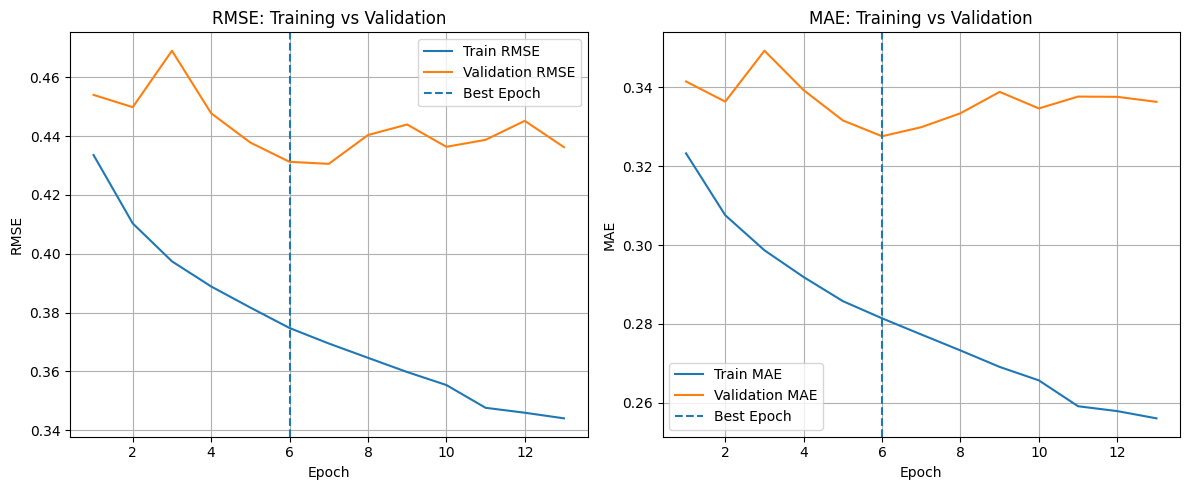

In [35]:
epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- RMSE plot ---
ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

# --- MAE plot ---
ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.savefig(model_figs, dpi=300, bbox_inches="tight")
plt.show()

In [37]:
def compute_group_mae(df, group_col):
    group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))

    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group

    return group_mae, worst_group, gap

def collect_predictions(model, df, loader):
    model.eval()

    results = []

    total_time = 0
    total_samples = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")

        for imgs, labels, idx in pbar:
            imgs = imgs.to(device)

            start = time.time()
            preds = model(imgs)
            end = time.time()

            batch_time = end - start

            total_time += batch_time
            total_samples += imgs.size(0)

            preds = preds.cpu().numpy()

            for i in range(len(preds)):
                row = df.iloc[idx[i].item()]

                results.append({
                    "pred": preds[i],
                    "true": labels[i].item(),
                    "gender": row["gender_name"],
                    "age": row["age"]
                })

    results_df = pd.DataFrame(results)

    # --- metrics ---
    mae = np.mean(np.abs(results_df["true"] - results_df["pred"]))
    rmse = np.sqrt(np.mean((results_df["true"] - results_df["pred"])**2))

    latency_per_batch = total_time / len(loader)
    latency_per_sample = total_time / total_samples

    return results_df, mae, rmse, latency_per_batch, latency_per_sample


def compute_fairness_metrics(results_df):
    metrics = {}

    # ---- Gender ----
    gender_mae, gender_worst, gender_gap = compute_group_mae(results_df, "gender")

    metrics["gender"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in gender_mae.items()},
        "worst_group_mae": round(float(gender_worst), 5),
        "gap": round(float(gender_gap), 5)
    }

    # ---- Age ----
    results_df = results_df.copy()
    results_df["age_group"] = pd.cut(results_df["age"], bins=[13, 17, 20, 22, 26, 44])

    age_mae, age_worst, age_gap = compute_group_mae(results_df, "age_group")

    metrics["age"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in age_mae.items()},
        "worst_group_mae": round(float(age_worst), 5),
        "gap": round(float(age_gap), 5)
    }

    return metrics

In [38]:
model_path = "models/sensors_baseline.pt"
model_results = "results/sensors_results.json"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SensorModel(input_dim=len(sensor_cols)).to(device)

model.load_state_dict(torch.load(model_path))
model.eval()

/scratch-local/cfragkiadakis.22422360/ipykernel_2672547/342091778.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


SensorModel(
  (net): Sequential(
    (0): Linear(in_features=27, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [39]:
results_df, best_mae, best_rmse, best_latency_batch, best_latency_sample = collect_predictions(model, test_df, test_loader)
fairness_metrics = compute_fairness_metrics(results_df)
results = {
    "mae": round(float(best_mae),4),
    "rmse": round(float(best_rmse),4),
    "latency_per_batch": round(float(best_latency_batch),4),
    "latency_per_sample_ms": round(float(best_latency_sample * 1000),4),
    "fairness": fairness_metrics
}

with open(model_results, "w") as f:
    json.dump(results, f, indent=4)

Evaluating: 100%|██████████| 94/94 [00:01<00:00, 51.76it/s]
/scratch-local/cfragkiadakis.22422360/ipykernel_2672547/1838274659.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.22422360/ipykernel_2672547/1838274659.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.224223

In [40]:
print("MAE per gender:\n", results['fairness']['gender']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['gender']['worst_group_mae']}")
print(f"Gap: {results['fairness']['gender']['gap']}")

MAE per gender:
 {'female': 0.31992, 'male': 0.34348}

Worst-group MAE: 0.34348
Gap: 0.02357


In [41]:
print("MAE per age:\n", results['fairness']['age']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['age']['worst_group_mae']}")
print(f"Gap: {results['fairness']['age']['gap']}")

MAE per age:
 {'(13, 17]': 0.32157, '(17, 20]': 0.27902, '(20, 22]': 0.35297, '(22, 26]': 0.32979, '(26, 44]': 0.39424}

Worst-group MAE: 0.39424
Gap: 0.11522
